# ERA5 Retrieval Test (gcsfs)

This notebook pulls a small representative ERA5 cube from ARCO Zarr on GCS using `gcsfs`, visualizes it, and shows a payload size estimate for internet streaming.

In [1]:
from __future__ import annotations

from io import BytesIO
import gzip
from pathlib import Path
import sys

import gcsfs
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Project root:", PROJECT_ROOT)

Project root: /Users/chxmr/code/glide


## Configure ARCO ERA5 Store

The first accessible path from `STORE_CANDIDATES` is used.

In [2]:
STORE_CANDIDATES = [
    "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
    #"gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr",
]

fs = gcsfs.GCSFileSystem(token="anon")

def open_first_available_store(paths: list[str]) -> tuple[xr.Dataset, str]:
    errors = []
    for path in paths:
        try:
            mapper = fs.get_mapper(path)
            ds = xr.open_zarr(mapper, consolidated=True)
            return ds, path
        except Exception as exc:
            errors.append((path, str(exc)))
    details = "\n".join([f"- {p}: {e}" for p, e in errors])
    raise RuntimeError(f"Could not open any ERA5 store.\n{details}")

ds, store_path = open_first_available_store(STORE_CANDIDATES)
print("Opened store:", store_path)

I0402 14:23:21.663659  331291 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0402 14:23:21.676937  331309 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(100, generation: 1)


Opened store: gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3


In [3]:
def pick_name(dataset: xr.Dataset, candidates: list[str]) -> str:
    for name in candidates:
        if name in dataset.coords or name in dataset.dims or name in dataset.variables:
            return name
    raise KeyError(f"None of {candidates} found")

time_name = pick_name(ds, ["time", "valid_time"])
lat_name = pick_name(ds, ["latitude", "lat"])
lon_name = pick_name(ds, ["longitude", "lon"])
level_name = pick_name(ds, ["level", "pressure_level", "isobaricInhPa"])

print("Coord names:")
print(" time:", time_name)
print(" lat :", lat_name)
print(" lon :", lon_name)
print(" z   :", level_name)

Coord names:
 time: time
 lat : latitude
 lon : longitude
 z   : level


## Retrieve a Small Representative Cube

This intentionally keeps data tiny so it is realistic for streaming over the internet.

In [9]:
preferred_vars = ["u_component_of_wind", "v_component_of_wind", "vertical_velocity", "boundary_layer_height"]
available_vars = [v for v in preferred_vars if v in ds.data_vars]
if not available_vars:
    available_vars = list(ds.data_vars)[:2]

print("Using variables:", available_vars)

t_slice = slice(ds[time_name].values[1000000], ds[time_name].values[1000001])

lat_vals = ds[lat_name].values
lon_vals = ds[lon_name].values
lev_vals = ds[level_name].values

lat_center = float(lat_vals[len(lat_vals) // 2])
lon_center = float(lon_vals[len(lon_vals) // 2])

lat_min, lat_max = lat_center - 2.0, lat_center + 2.0
lon_min, lon_max = lon_center - 2.0, lon_center + 2.0

level_subset = lev_vals[: min(4, len(lev_vals))]

lat_desc = bool(lat_vals[0] > lat_vals[-1])
lat_slice = slice(lat_max, lat_min) if lat_desc else slice(lat_min, lat_max)


Using variables: ['u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'boundary_layer_height']


In [10]:
cube = ds[available_vars].sel(
    {
        time_name: t_slice,
        lat_name: lat_slice,
        lon_name: slice(lon_min, lon_max),
        level_name: level_subset,
    }
).astype(np.float32).compute()

cube

<xarray.Dataset> Size: 30kB
Dimensions:                (time: 2, level: 4, latitude: 17, longitude: 17)
Coordinates:
  * time                   (time) datetime64[ns] 16B 2014-01-29T16:00:00 2014...
  * level                  (level) int64 32B 1 2 3 5
  * latitude               (latitude) float32 68B 2.0 1.75 1.5 ... -1.75 -2.0
  * longitude              (longitude) float32 68B 178.0 178.2 ... 181.8 182.0
Data variables:
    u_component_of_wind    (time, level, latitude, longitude) float32 9kB -25...
    v_component_of_wind    (time, level, latitude, longitude) float32 9kB 1.5...
    vertical_velocity      (time, level, latitude, longitude) float32 9kB -0....
    boundary_layer_height  (time, latitude, longitude) float32 2kB 794.5 ... ...
Attributes:
    last_updated:           2026-04-02 02:31:50.473162+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-03-27

## Quick Visual Check

Plots the first variable at first time and first vertical level.

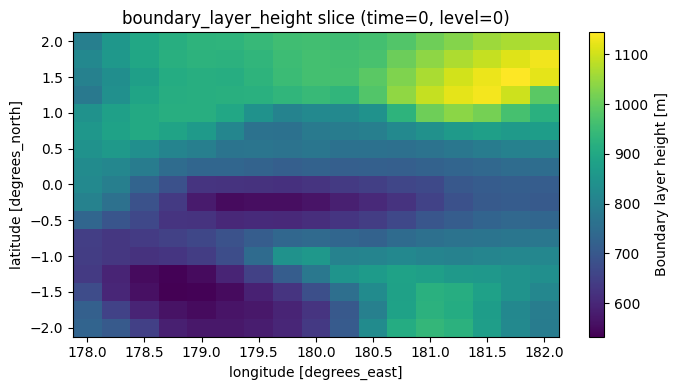

In [14]:
var0 = list(cube.data_vars)[3]
da0 = cube[var0]

# Assumes variable dims include [time, level, lat, lon] in some order.
indexer = {dim: 0 for dim in da0.dims if dim in {time_name, level_name}}
img = da0.isel(indexer)

plt.figure(figsize=(7, 4))
img.plot(cmap="viridis")
plt.title(f"{var0} slice (time=0, level=0)")
plt.tight_layout()
plt.show()

## Optional: Save Test Cube Locally

Useful for repeated debugging without hitting GCS each run.

In [ ]:
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
local_test_cube = out_dir / "era5_test_cube.nc"
cube.to_netcdf(local_test_cube)
print("Saved:", local_test_cube)